# U-Net：TGS 盐层二值语义分割——数据处理逐行说明

建议从上到下运行。流程是：找到文件 → 同名配对 → 检查掩码 → 可视化 → 划分训练/验证 → Dataset 读取单张图 → DataLoader 组成 batch → 接入 U-Net。

数据根目录为 D:\code\Blog\archive\competition_data。实测训练图像和掩码各 4000 张，测试图像 18000 张。掩码混用 8 位和 16 位 PNG；非空掩码的前景值可能是 65535，必须先用“像素 > 0”统一为二值标签。

### 第一个代码单元中的工具

| 导入 | 用途 |
| --- | --- |
| pathlib.Path | 管理路径，使用 / 拼接子目录。 |
| collections.Counter | 统计不同 PNG 模式各有多少张。 |
| sys | 确认当前 Python 环境。 |
| matplotlib.pyplot | 显示原图、掩码和叠加图。 |
| numpy | 像素数组、统计、分组及二值化。 |
| PIL.Image | 打开、转灰度和缩放 PNG。 |
| torch | 将数据转为张量，计算损失。 |
| Dataset / DataLoader | 定义单个样本如何读取；按批次迭代。 |

Path(r"...") 的 r 防止 Windows 路径中的反斜杠被当成转义字符。ROOT / "train" / "images" 是路径拼接。is_dir() 检查目录存在；assert 在检查失败时立即报错。

In [1]:
# Path 管理文件路径。
from pathlib import Path
from collections import Counter
import sys
import matplotlib.pyplot as plt
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader

# 原始字符串 r 保留 Windows 路径中的反斜杠。
ROOT = Path(r"D:\code\Blog\archive\competition_data")
TRAIN_IMAGES = ROOT / "train" / "images"
TRAIN_MASKS = ROOT / "train" / "masks"
TEST_IMAGES = ROOT / "test" / "images"
# 先检查必需目录是否存在。
for folder in (TRAIN_IMAGES, TRAIN_MASKS, TEST_IMAGES):
    assert folder.is_dir(), f"缺少目录: {folder}"
print("Python:", sys.executable, "PyTorch:", torch.__version__)

Python: d:\JupyterLab\.venv\Scripts\python.exe PyTorch: 2.5.1+cu121


## 1. 图像和掩码怎样配对、检查？

- glob("*.png") 列出目录中的 PNG。p.stem 是去掉扩展名的 ID；例如 003c477d7c.png 的 stem 是 003c477d7c。字典把 ID 映射到路径，两边相同 ID 就是一对。
- images.keys() == masks.keys() 检查没有缺失配对；sorted(images) 给 ID 固定顺序，便于复现后面的随机划分。
- with Image.open(...) 同时打开原图和掩码，离开 with 后自动关闭。size 相等说明空间位置能一一对应。
- np.asarray(mask) 转成像素数组；np.unique(a) 找像素取值；np.count_nonzero(a) 统计盐层像素数；a.size 是总像素数。两者相除得到盐层覆盖率。
- Counter 统计 PNG 模式；np.quantile 给出覆盖率的分位数。最后的 assert 用于发现意外像素值。

这里的原始掩码值是 0 或 65535。不能用 mask == 255 判断前景，否则会漏掉盐层。训练时统一转成 0/1。

In [ ]:
# glob 找 PNG；stem 取文件 ID，建立 ID 到路径的映射。
images = {p.stem: p for p in TRAIN_IMAGES.glob("*.png")}
# 掩码建立同样的 ID 到路径映射。
masks = {p.stem: p for p in TRAIN_MASKS.glob("*.png")}
test_files = sorted(TEST_IMAGES.glob("*.png"))
# 原图与掩码必须一一配对。
assert images.keys() == masks.keys(), "图像与掩码文件名不匹配"
#     按编号排序
# 固定 ID 顺序，便于复现划分。
ids = sorted(images)
# 保存每张图的盐层覆盖率。
coverage = []
#                                 计数器                集合
image_modes, mask_modes, values = Counter(), Counter(), set()
for sample_id in ids:
    # 同名打开一张图及其掩码，离开 with 自动关闭。
    with Image.open(images[sample_id]) as im, Image.open(masks[sample_id]) as mask:
        assert im.size == mask.size, f"尺寸不匹配: {sample_id}"
        # 统计不同模式数量
        image_modes[im.mode] += 1
        mask_modes[mask.mode] += 1
        # 保留掩码原始像素值，包括 16 位的 65535。
        a = np.asarray(mask)
        # 收集出现过的像素值。
        values.update(np.unique(a).tolist())
        # 非零像素数除以总像素数。
        coverage.append(np.count_nonzero(a) / a.size)
coverage = np.asarray(coverage, dtype=np.float32)
print("训练配对:", len(ids), "测试图片:", len(test_files))
print("图像模式:", dict(image_modes), "掩码模式:", dict(mask_modes))
print("掩码像素值:", sorted(values))
print("空掩码数:", int(np.count_nonzero(coverage == 0)))
print("覆盖率分位数:", np.quantile(coverage, [0, .25, .5, .75, 1]))
assert values <= {0, 255, 65535}, "发现新像素值，请先检查掩码"

训练配对: 4000 测试图片: 18000
图像模式: {'RGBA': 3040, 'RGB': 960} 掩码模式: {'L': 1562, 'I;16': 2438}
掩码像素值: [0, 65535]
空掩码数: 1562
覆盖率分位数: [0.         0.         0.05548476 0.46926773 0.99990195]


## 2. 可视化检查为什么必要？

choices 选三张代表性图片：空掩码、盐层覆盖率接近 10%、接近 70%。np.abs 求与目标覆盖率的距离，np.argmin 取距离最小的下标。

plt.subplots(3, 3) 建立 3 行 3 列画布。每行依次是原图、二值掩码、叠加图。convert("L") 将原图转灰度；np.asarray(mask) > 0 把原始掩码变成布尔数组。

灰度图形状是 [H,W]。x[..., None] 加一个通道维，np.repeat(...,3,axis=2) 复制为 [H,W,3]；overlay[y] 只选择盐层像素，加红色便于检查边界。overlay 仅用于展示，不参与训练。若红色区域错位，应先检查配对或缩放。

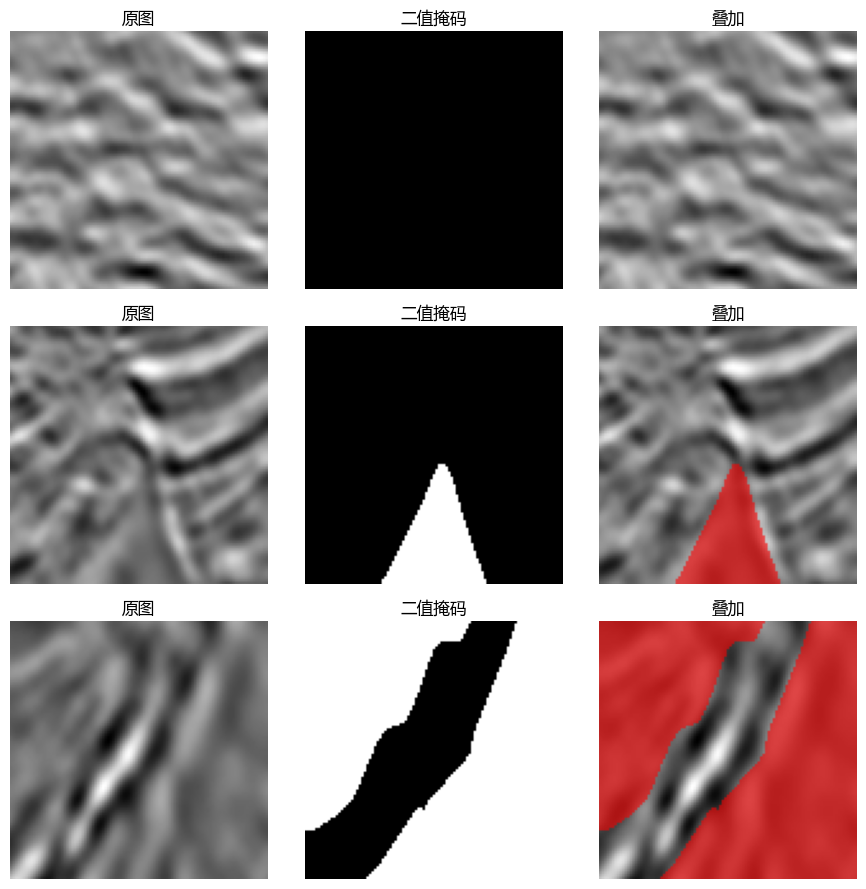

In [3]:
#                 下标
# 选空掩码、约 10% 和约 70% 覆盖率的例子。
choices = [int(np.argmin(coverage)),
           int(np.argmin(np.abs(coverage - .10))),
           int(np.argmin(np.abs(coverage - .70)))]
# 3 行样本，每行原图、掩码、叠加图三列。
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for row, idx in enumerate(choices):
    sample_id = ids[idx]
    with Image.open(images[sample_id]) as im, Image.open(masks[sample_id]) as mask:
        # 原图转灰度，掩码转为布尔值。
        x = np.asarray(im.convert("L"))
        y = np.asarray(mask) > 0
    # 将灰度图复制成三通道，便于加红色。
    overlay = np.repeat(x[..., None], 3, axis=2).astype(np.float32)
    # 只给盐层位置加红色；不影响训练数据。
    overlay[y] = overlay[y] * .4 + np.array([153, 0, 0])
    axes[row, 0].imshow(x, cmap="gray", vmin=0, vmax=255)
    axes[row, 1].imshow(y, cmap="gray", vmin=0, vmax=1)
    axes[row, 2].imshow(overlay.astype(np.uint8))
    axes[row, 0].set_ylabel(f"{sample_id}\n覆盖率 {coverage[idx]:.1%}")
    for col, title in enumerate(("原图", "二值掩码", "叠加")):
        axes[row, col].set_title(title)
        axes[row, col].axis("off")
plt.tight_layout()
plt.show()

## 3. 如何划分训练集和验证集？

rng = np.random.default_rng(42) 创建固定种子的随机数生成器，使每次运行的划分一致。strata 把空掩码放在第 0 组，非空掩码按覆盖率分为第 1～4 组；例如 10% 进入第 1 组，70% 进入第 3 组。

np.unique(strata) 列出组号；np.flatnonzero(strata == group) 找当前组的样本下标；rng.shuffle 就地打乱。每组约 20% 放入 val_ids，其余放入 train_ids。最后的两个 assert 检查训练/验证不重叠、也没有遗漏样本。

实际结果是 3201 张训练、799 张验证。划分先于数据增强，避免同一张图的两个变体分别出现在训练与验证中。ID 排序和随机种子固定，因此重新运行可复现划分。

In [4]:
# 固定随机种子，使划分可复现。
rng = np.random.default_rng(42)
# 空掩码为第 0 组，其余按覆盖率分组。
strata = np.where(coverage == 0, 0, np.minimum(np.ceil(coverage * 4).astype(int), 4))
train_ids, val_ids = [], []
for group in sorted(np.unique(strata)):
    # 取得当前组的所有样本下标。
    group_indices = np.flatnonzero(strata == group)
    # 在组内打乱样本。
    rng.shuffle(group_indices)
    # 当前组约 20% 作为验证集。
    n_val = max(1, round(len(group_indices) * .2))
    val_ids.extend(ids[i] for i in group_indices[:n_val])
    train_ids.extend(ids[i] for i in group_indices[n_val:])
rng.shuffle(train_ids)
rng.shuffle(val_ids)
# 检查训练和验证没有相同图像。
assert set(train_ids).isdisjoint(val_ids)
assert set(train_ids) | set(val_ids) == set(ids)
coverage_by_id = dict(zip(ids, coverage))
print("训练:", len(train_ids), "空掩码:", sum(coverage_by_id[i] == 0 for i in train_ids))
print("验证:", len(val_ids), "空掩码:", sum(coverage_by_id[i] == 0 for i in val_ids))

训练: 3201 空掩码: 1250
验证: 799 空掩码: 312


## 4. Dataset 和 DataLoader 做什么？

Dataset 是“读取一个样本的规则”：__init__ 保存路径和配置，__len__ 返回样本数，__getitem__(index) 真正打开一张图并返回处理结果。并不在 __init__ 中把 4000 张图全加载到内存。

图像：Image.open → convert("L") 单通道灰度 → resize(BILINEAR) 缩放至 128×128 → np.asarray(...,float32) → 除以 255，得到范围 [0,1]。

掩码：先读原始像素，用 raw > 0 兼容 16 位前景 65535；转成 0/255 的 8 位图；resize(NEAREST) 最近邻缩放，避免产生虚假的中间类别；最终转成 0/1 浮点数组。图像可以平滑插值，掩码是离散标签，只能用最近邻。

若 mask_dir 为 None，就是无标签测试集，只返回图像和 ID。augment=True 时训练图像和掩码同步水平翻转；ascontiguousarray 把翻转产生的非连续数组整理成 PyTorch 可读取的布局。x[None] 将 [128,128] 变成 [1,128,128]，torch.from_numpy 再转为张量。

DataLoader 每次调用 Dataset 的 __getitem__。batch_size=8 组成 8 张的 batch；shuffle=True 每轮打乱训练样本；num_workers=0 让读取在当前进程进行，便于 Windows/Jupyter 排查问题。next(iter(train_loader)) 取第一个 batch；assert 检查图像和掩码均为 [8,1,128,128]，掩码只含 0/1。

In [ ]:
# 定义 PyTorch 数据集，按下标读取一张样本。
class TGSSaltDataset(Dataset):
    # 保存 ID、路径、尺寸和是否增强。
    def __init__(self, ids, image_dir, mask_dir=None, size=128, augment=False):
        self.ids = list(ids)
        self.image_dir = Path(image_dir)
        self.mask_dir = Path(mask_dir) if mask_dir is not None else None
        self.size = size
        self.augment = augment

    # 告诉 DataLoader 数据集有多少张图。
    def __len__(self):
        return len(self.ids)

    # DataLoader 每取一张图就调用这个方法。
    def __getitem__(self, index):
        sample_id = self.ids[index]
        with Image.open(self.image_dir / f"{sample_id}.png") as im:
            # 原图用双线性插值缩放；它是连续亮度。
            im = im.convert("L").resize(
                (self.size, self.size), Image.Resampling.BILINEAR)
            # 图像转 float32，再归一化至 0~1。
            x = np.asarray(im, dtype=np.float32).copy() / 255.0
        # 测试集没有掩码。
        if self.mask_dir is None:
            return torch.from_numpy(x[None]).float(), sample_id
        with Image.open(self.mask_dir / f"{sample_id}.png") as mask:
            # 先保留 8/16 位原始掩码值。
            raw = np.asarray(mask)
            # 所有非零像素统一标为盐层。
            binary = Image.fromarray((raw > 0).astype(np.uint8) * 255, mode="L")
            # 掩码用最近邻缩放，保持类别离散。
            binary = binary.resize(
                (self.size, self.size), Image.Resampling.NEAREST)
            y = (np.asarray(binary) > 0).astype(np.float32)
        # 训练时 50% 概率同步翻转图像与掩码。
        if self.augment and np.random.rand() < .5:
            x = np.ascontiguousarray(x[:, ::-1])
            y = np.ascontiguousarray(y[:, ::-1])
        # 加通道维，并把 NumPy 数组转为 PyTorch 张量。
        return (torch.from_numpy(x[None]).float(),
                torch.from_numpy(y[None]).float(), sample_id)

In [ ]:
# 训练集增强；验证集不增强；测试集无掩码。
train_data = TGSSaltDataset(train_ids, TRAIN_IMAGES, TRAIN_MASKS, augment=True)
val_data = TGSSaltDataset(val_ids, TRAIN_IMAGES, TRAIN_MASKS)
test_data = TGSSaltDataset([p.stem for p in test_files], TEST_IMAGES)
# 每批 8 张，训练时打乱。
train_loader = DataLoader(train_data, batch_size=8, shuffle=True, num_workers=0)
val_loader = DataLoader(val_data, batch_size=8, shuffle=False, num_workers=0)

# 取首批样本检查真实输出。
batch_x, batch_y, batch_ids = next(iter(train_loader))
print("图像:", tuple(batch_x.shape), batch_x.dtype,
      (batch_x.min().item(), batch_x.max().item()))
print("掩码:", tuple(batch_y.shape), batch_y.dtype,
      torch.unique(batch_y).tolist())
# 确认图像与掩码的批次、通道、高宽一致。
assert batch_x.shape == batch_y.shape == (8, 1, 128, 128)
assert set(torch.unique(batch_y).tolist()) <= {0.0, 1.0}

## 5. 这些数据怎样接入 U-Net？

本任务仅区分盐层和背景。U-Net 第一层输入通道数应为 1，最后的 1×1 卷积输出通道数应为 1，因此模型输出 logits 与掩码都是 [B,1,128,128]。

BCEWithLogitsLoss 将 sigmoid 和二元交叉熵合在一起；训练时直接调用 criterion(model(batch_x), batch_y)，不要先手动 sigmoid。推理时才做 torch.sigmoid(logits) > 0.5。下面的 dummy_logits 是全零占位张量，仅用来检查损失函数的输入接口，不是模型预测。

测试集没有真值掩码，不能用于本地验证。depths.csv 的深度信息留待后续模型；初版先只用图像。预测测试图时，应先把 128×128 概率图恢复到原始 101×101，再二值化。

In [ ]:
# 单通道二值分割损失；内部含 sigmoid。
criterion = torch.nn.BCEWithLogitsLoss()
# 占位数据，仅检查形状，不是模型输出。
dummy_logits = torch.zeros_like(batch_y)  # 之后替换为 model(batch_x)
print("期望输出:", tuple(dummy_logits.shape),
      "示例损失:", criterion(dummy_logits, batch_y).item())
print("测试输入:", tuple(test_data[0][0].shape), "ID:", test_data[0][1])

## 数据处理函数速查

| 函数或写法 | 输入 → 输出 | 本 notebook 的用途 |
| --- | --- | --- |
| Path / 路径相除 | 字符串 → 路径 | 管理 Windows 路径和子目录。 |
| glob("*.png") | 目录 → 文件路径序列 | 查找 PNG。 |
| p.stem | 路径 → 不带扩展名的 ID | 配对原图和掩码。 |
| Image.open | 路径 → PIL 图像 | 按需读取一张图片。 |
| convert("L") | RGB/RGBA → 灰度 | 得到单通道输入。 |
| np.asarray | PIL 图像 → NumPy 数组 | 计算像素。 |
| np.unique | 数组 → 不重复取值 | 核查掩码像素值。 |
| np.count_nonzero | 数组 → 非零像素数 | 计算盐层覆盖率。 |
| np.where / np.flatnonzero | 条件 → 分组值或下标 | 分层划分。 |
| resize(BILINEAR) | 图像 → 缩放图像 | 平滑缩放原图。 |
| resize(NEAREST) | 掩码 → 缩放掩码 | 保持 0/1 标签。 |
| torch.from_numpy | NumPy 数组 → 张量 | 交给模型。 |
| DataLoader | Dataset → batch 迭代器 | 批量读取和打乱。 |

**记忆重点：图像是连续亮度，可以平滑插值；掩码是离散类别，只能保持原有标签。**